In [12]:
%load_ext kedro.ipython

from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
)

random_state = catalog.load('params:model_options.random_state')

                    INFO     Loading data from params:model_options.random_state                ]8;id=668630;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=486163;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\
                             (MemoryDataset)...                                                                    

In [3]:
X_test, y_test = catalog.load('TI_test_feature'), catalog.load('TI_y_test_feature')
y_test = pd.DataFrame(y_test).T.iloc[0]

                    INFO     Loading data from TI_test_feature (CSVDataset)...                  ]8;id=930913;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=166313;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_y_test_feature (CSVDataset)...                ]8;id=41647;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=403150;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

### Cross-validation with Undersampling (pre-trained)

In [4]:
best_estimators = catalog.load('logit_trained')

                    INFO     Loading data from logit_trained (PickleDataset)...                 ]8;id=863380;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=498578;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

In [5]:
best_scores = []

for b_est_idx, best_est in enumerate(best_estimators):
    y_pred = best_est.predict(X_test)
    y_proba = best_est.predict_proba(X_test)[:, 1]

    f1_test = f1_score(y_test, y_pred, pos_label=True)
    pr_test = precision_score(y_test, y_pred, pos_label=True)
    recall_test = recall_score(y_test, y_pred, pos_label=True)
    avg_pr_test = average_precision_score(y_test, y_pred, pos_label=True)

    best_scores.append([])

    best_scores[b_est_idx].append(0.1 + b_est_idx * 0.1)
    best_scores[b_est_idx].append(best_est.best_score_)
    best_scores[b_est_idx].append(f1_test)
    best_scores[b_est_idx].append(pr_test)
    best_scores[b_est_idx].append(recall_test)
    best_scores[b_est_idx].append(avg_pr_test)

best_scores_df = pd.DataFrame(
    best_scores,
    columns=[
        'undersampling_size',
        'avg_precision_train',
        'f1_test',
        'precision_test',
        'recall_test',
        'avg_precision_test',
    ],
)


best_scores_df

,undersampling_size,avg_precision_train,f1_test,precision_test,recall_test,avg_precision_test
0,0.1,0.074253,0.086237,0.046057,0.675676,0.035857


We got decent recall for positive class, but precision is bad. I think, for this problem of insurance claim, recall is more important (it's important to detect claim situations), although this will lead for claim approval where they shouldn't have been approved.

In [6]:
best_est.best_params_

{'class_weight': 'balanced', 'penalty': None, 'solver': 'saga'}

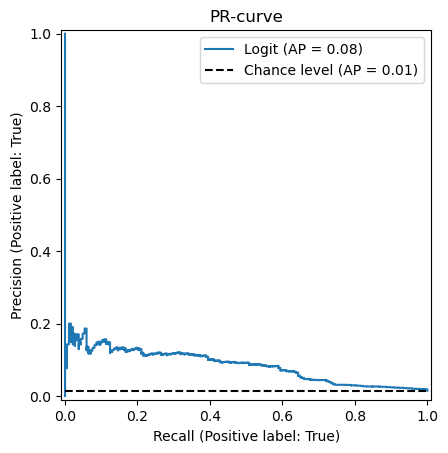

In [ ]:
display = PrecisionRecallDisplay.from_estimator(
    best_est, X_test, y_test, name="Logit", plot_chance_level=True
)
_ = display.ax_.set_title("PR-curve")
plt.legend()
plt.show()